In [5]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

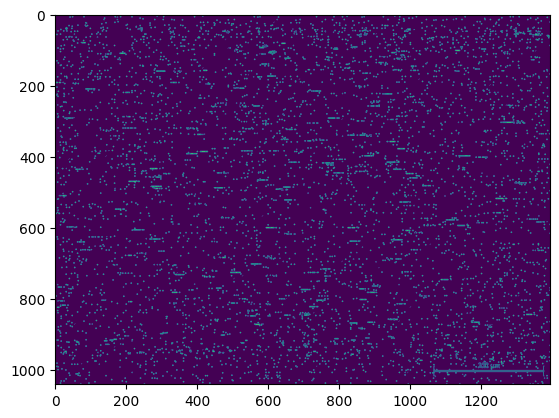

In [9]:
############### PARAMETERS ###############
impath = "./Microfluids Nov 6 12pm/case1_200um_2.jpg"
SCALE = 200 # length of scale bar (um)
TARGET = 500 # Designate intended height position from top (um)
threshold = 20 # Allowed range form top and bottom of either side of TARGET

# Edge Detection
img = cv2.imread(impath, cv2.IMREAD_GRAYSCALE)
img = cv2.convertScaleAbs(img, 2, 1)
img = cv2.adaptiveThreshold(img,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY,3,-2)
plt.imshow(img)

# Apply edge detection method on the image
edges = cv2.Canny(img, 100, 200, apertureSize=3)
plt.imshow(edges)

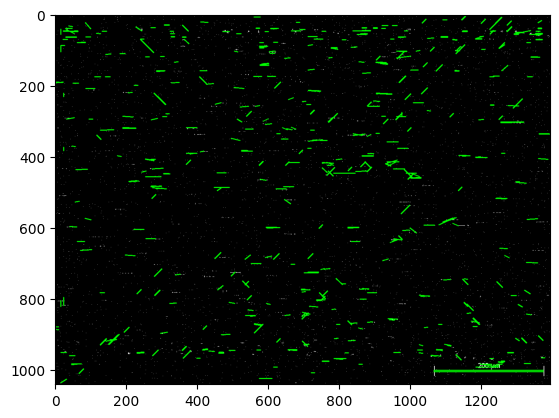

In [10]:
lines = cv2.HoughLinesP(edges, 
                        rho=1, 
                        theta=np.pi/180, 
                        threshold=70, 
                        minLineLength=10,
                        maxLineGap=10)

# Display the result on a colour version
output_image = cv2.imread(impath)
output_image = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # BGR reverse to RGB

output_image_alllines = output_image.copy()

# Draw the detected lines on the image
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(output_image_alllines, (x1, y1), (x2, y2), (0, 255, 0), 2)

# Display the result
plt.imshow(output_image_alllines)

Number of lines = 28
Average length = 12.6364324807293 um
Sigma = 3.487199683235078


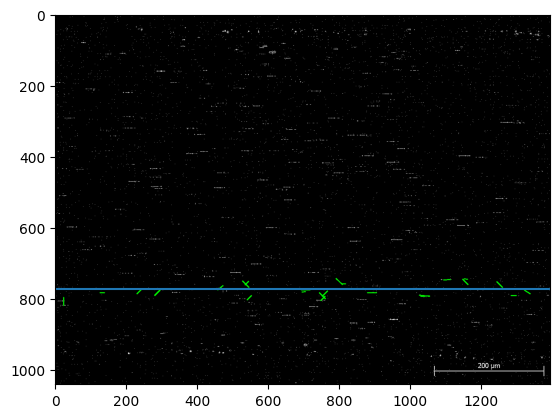

In [11]:
lines = np.array(lines)
# Calculate the length of each line
linel_norms = []
for line in lines:
    x1, y1, x2, y2 = line[0]
    # Use NumPy to calculate the Euclidean distance (pixels)
    length = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    linel_norms.append(length)

linel_norms = np.array(linel_norms)
scalefactor = SCALE/max(linel_norms)
linel_norms = linel_norms*scalefactor

# Filter lines that start/end too far from the intended zone - masking
mask = np.zeros(linel_norms.shape[0], dtype=bool)
for i in range(len(lines)):
    x1, y1, x2, y2 = lines[i][0]
    # Check if either endpoint is within the threshold
    if abs(y1 - TARGET/scalefactor) <= threshold/scalefactor or abs(y2 - TARGET/scalefactor) <= threshold/scalefactor:
        mask[i] = True
linel_norms = linel_norms[mask]

# Display the result on a colour version
if lines is not None:
    for line in lines[mask]:
        x1, y1, x2, y2 = line[0]
        cv2.line(output_image, (x1, y1), (x2, y2), (0, 255, 0), 2)
plt.axhline(TARGET/scalefactor)
plt.imshow(output_image)

print(f"Number of lines = {linel_norms.shape[0]}\nAverage length = {np.mean(linel_norms)} um\nSigma = {np.std(linel_norms)}")